# Séance 4 : Programmation Dynamique
## M1 Mathématiques – Informatique pour Mathématiciens
### Université d'Antananarivo – Année 2026–2027

---

**Objectifs de cette séance :**
1. Comprendre le principe de la programmation dynamique (mémoïsation vs tabulisation)
2. Implémenter Fibonacci (3 versions), LCS, Levenshtein, Knapsack 0/1
3. Concevoir la classe abstraite `TableDP`
4. Mesurer empiriquement les complexités

**Ressources :** CLRS ch. 15–16 · Exo7 · Mathematics in Lean (section 5)

In [1]:
# ─── Imports globaux ───────────────────────────────────────────────────────────
import time
import sys
import functools
import matplotlib.pyplot as plt
import numpy as np
from abc import ABC, abstractmethod

sys.setrecursionlimit(50000)
print("Environnement prêt.")

Environnement prêt.


---
## Partie 1 : Fibonacci – Trois Versions

La suite de Fibonacci est définie par :
$$F_0 = 0,\quad F_1 = 1,\quad F_n = F_{n-1} + F_{n-2} \quad (n \geq 2)$$

### 1.1 Version naïve (récursive)

Complexité : $O(2^n)$ — **inutilisable au-delà de $n \approx 40$**.

In [2]:
def fibonacci_naif(n):
    """
    Fibonacci naïf par double récursion.
    Complexité : O(2^n) temps, O(n) espace (pile).
    """
    if n <= 1:
        return n
    return fibonacci_naif(n - 1) + fibonacci_naif(n - 2)
    raise NotImplementedError("À implémenter")

# ── Tests ──────────────────────────────────────────────────────────────────────
premiers_fib = [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
for i, val in enumerate(premiers_fib):
    assert fibonacci_naif(i) == val, f"Erreur pour n={i}"
print("fibonacci_naif : OK")

fibonacci_naif : OK


### 1.2 Version mémoïsée (top-down)

Complexité : $O(n)$ temps et espace.

In [3]:
def fibonacci_memo(n, cache=None):
    """
    Fibonacci par mémoïsation (top-down).
    Complexité : O(n) temps et espace.
    """
    if cache is None:
        cache = {}
    if n in cache:
        return cache[n]
    if n <= 1:
        return n
    cache[n] = fibonacci_memo(n - 1, cache) + fibonacci_memo(n - 2, cache)
    return cache[n]
    raise NotImplementedError("À implémenter")

# ── Tests ──────────────────────────────────────────────────────────────────────
for i, val in enumerate(premiers_fib):
    assert fibonacci_memo(i) == val, f"Erreur pour n={i}"
assert fibonacci_memo(50) == 12586269025
print("fibonacci_memo : OK")

fibonacci_memo : OK


### 1.3 Version tabulaire (bottom-up)

Complexité : $O(n)$ temps, **$O(1)$ espace**.

In [4]:
def fibonacci_tab(n):
    """
    Fibonacci par tabulisation (bottom-up).
    Complexité : O(n) temps, O(1) espace.
    Indice : seuls les deux derniers termes sont nécessaires.
    """
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

    raise NotImplementedError("À implémenter")

# ── Tests ──────────────────────────────────────────────────────────────────────
for i, val in enumerate(premiers_fib):
    assert fibonacci_tab(i) == val, f"Erreur pour n={i}"
assert fibonacci_tab(100) == 354224848179261915075
print("fibonacci_tab : OK")

fibonacci_tab : OK


### 1.4 Comparaison empirique des trois versions

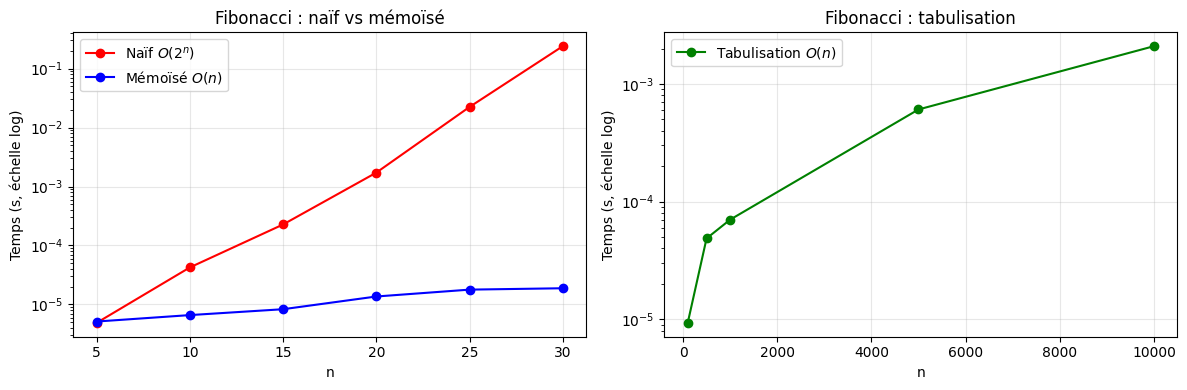

In [5]:
# ── Mesures de temps ───────────────────────────────────────────────────────────
# TODO : mesurez les temps d'exécution des trois versions
# pour n = [5, 10, 15, 20, 25, 30] (naïf) et n = [100, 500, 1000, 5000] (memo+tab)
# Tracez les courbes sur deux graphiques distincts.

# Squelette
n_naif = [5, 10, 15, 20, 25, 30]
temps_naif = []
temps_memo = []

for n in n_naif:
    # Mesurez fibonacci_naif(n)
    debut = time.perf_counter()
    fibonacci_naif(n)
    temps_naif.append(time.perf_counter() - debut)
    
    # Mesurez fibonacci_memo(n, {})
    debut = time.perf_counter()
    fibonacci_memo(n, {})
    temps_memo.append(time.perf_counter() - debut)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : comparaison naïf vs mémo (petites valeurs)
axes[0].semilogy(n_naif, temps_naif, 'r-o', label='Naïf $O(2^n)$')
axes[0].semilogy(n_naif, temps_memo, 'b-o', label='Mémoïsé $O(n)$')
axes[0].set_xlabel('n')
axes[0].set_ylabel('Temps (s, échelle log)')
axes[0].set_title('Fibonacci : naïf vs mémoïsé')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : TODO — mémo vs tab pour grandes valeurs
n_grand = [100, 500, 1000, 5000, 10000]
temps_tab = []

for n in n_grand:
    debut = time.perf_counter()
    fibonacci_tab(n)
    temps_tab.append(time.perf_counter() - debut)

axes[1].semilogy(n_grand, temps_tab, 'g-o', label='Tabulisation $O(n)$')
axes[1].set_xlabel('n')
axes[1].set_ylabel('Temps (s, échelle log)')
axes[1].set_title('Fibonacci : tabulisation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fibonacci_benchmark.png', dpi=100)
plt.show()

---
## Partie 2 : Décorateur `@memoize`

Un décorateur est une fonction qui prend une fonction en entrée et retourne une fonction enrichie.

In [6]:
def memoize(func):
    """
    Décorateur de mémoïsation générique.
    Stocke les résultats dans un dictionnaire cache.
    Applicable à toute fonction dont les arguments sont hashables.
    """
    
    # Indices :
    # 1. Créer un dictionnaire cache = {}
    # 2. Définir wrapper(*args) qui vérifie le cache avant d'appeler func
    # 3. Attacher cache et cache_info à wrapper
    # 4. Retourner wrapper

    cache = {}
    @functools.wraps(func)
    def wrapper(*args):
        if args not in cache:
            cache[args]=func(*args)
        return cache[args]

    wrapper.cache = cache
    wrapper.cache_info = lambda: f"ABC : {len(cache)} valeurs mémorisées"
    return wrapper
    #raise NotImplementedError("À implémenter")

        

@memoize
def fib_dec(n):
    if n <= 1:
        return n
    return fib_dec(n - 1) + fib_dec(n - 2)

# ── Tests ──────────────────────────────────────────────────────────────────────
assert fib_dec(50) == 12586269025
assert len(fib_dec.cache) == 51  # 51 valeurs mémorisées (F_0 à F_50)
print("Décorateur memoize : OK")
print(fib_dec.cache_info())

Décorateur memoize : OK
ABC : 51 valeurs mémorisées


---
## Partie 3 : Plus Longue Sous-Séquence Commune (LCS)

**Définition :** la LCS de deux chaînes $X$ et $Y$ est la sous-séquence (non nécessairement contiguë) de longueur maximale commune aux deux.

**Relation de récurrence :**
$$c[i][j] = \begin{cases} 0 & \text{si } i=0 \text{ ou } j=0 \\ c[i-1][j-1]+1 & \text{si } x_i = y_j \\ \max(c[i-1][j], c[i][j-1]) & \text{sinon} \end{cases}$$

In [7]:
def lcs_longueur(X, Y):
    """
    Calcule la longueur de la LCS de X et Y par tabulisation.
    Complexité : O(m*n) temps et espace.
    Retourne : (longueur, table_c) pour permettre la reconstruction.
    Référence : CLRS, chapitre 15.4.
    """
    m, n = len(X), len(Y)
    c = [[0] * (n + 1) for _ in range(m + 1)]
    
    # Remplissage de la table
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i-1] == Y[j-1]:  # Les caractères correspondent
                c[i][j] = c[i-1][j-1] + 1
            else:  # Les caractères ne correspondent pas
                c[i][j] = max(c[i-1][j], c[i][j-1])
    
    return c[m][n], c

def lcs_reconstruire(X, Y, c):
    """
    Reconstruit une LCS à partir de la table c.
    Complexité : O(m+n).
    """
    lcs = []
    i, j = len(X), len(Y)
    while i > 0 and j > 0:
        if X[i-1] == Y[j-1]:
            lcs.append(X[i-1])
            i -= 1
            j -= 1
        elif c[i-1][j] > c[i][j-1]:
            i -= 1
        else:
            j -= 1
    return ''.join(reversed(lcs))

# ── Tests ──────────────────────────────────────────────────────────────────────
X, Y = "ABCBDAB", "BDCABA"
longueur, table = lcs_longueur(X, Y)
assert longueur == 4, f"Longueur attendue : 4, obtenu : {longueur}"

lcs = lcs_reconstruire(X, Y, table)
assert len(lcs) == 4, f"LCS de longueur 4 attendue, obtenu : {lcs}"
# Vérifier que lcs est bien une sous-séquence de X et Y
def est_sous_sequence(s, t):
    it = iter(t)
    return all(c in it for c in s)
assert est_sous_sequence(lcs, X) and est_sous_sequence(lcs, Y)

print(f"LCS('{X}', '{Y}') = '{lcs}' (longueur {longueur}) : OK")

# Cas limites
assert lcs_longueur("", "abc")[0] == 0
assert lcs_longueur("abc", "abc")[0] == 3
print("Cas limites LCS : OK")

LCS('ABCBDAB', 'BDCABA') = 'BDAB' (longueur 4) : OK
Cas limites LCS : OK


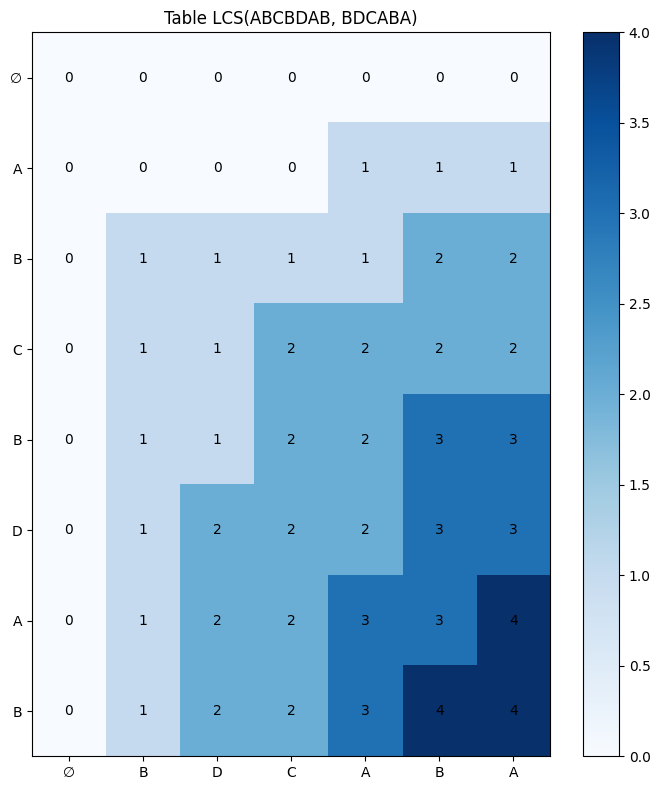

In [8]:
# ── Visualisation de la table DP ───────────────────────────────────────────────
def afficher_table_lcs(X, Y, c):
    """
    Affiche la table DP de la LCS sous forme de heatmap.
    """
    m, n = len(X), len(Y)
    fig, ax = plt.subplots(figsize=(n + 1, m + 1))
    
    # Heatmap de la table
    data = np.array(c)
    im = ax.imshow(data, cmap='Blues', aspect='auto')
    
    # Annotations
    for i in range(m + 1):
        for j in range(n + 1):
            ax.text(j, i, str(c[i][j]), ha='center', va='center', fontsize=10)
    
    ax.set_xticks(range(n + 1))
    ax.set_yticks(range(m + 1))
    ax.set_xticklabels(['∅'] + list(Y))
    ax.set_yticklabels(['∅'] + list(X))
    ax.set_title(f"Table LCS({X}, {Y})")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig('lcs_table.png', dpi=100)
    plt.show()

longueur, table = lcs_longueur(X, Y)
afficher_table_lcs(X, Y, table)

---
## Partie 4 : Distance d'Édition de Levenshtein

**Opérations autorisées :** insertion, suppression, substitution (coût 1 chacune).

**Relation de récurrence :**
$$d[i][j] = \begin{cases} i & \text{si } j=0 \\ j & \text{si } i=0 \\ d[i-1][j-1] & \text{si } x_i = y_j \\ 1 + \min(d[i-1][j],\; d[i][j-1],\; d[i-1][j-1]) & \text{sinon} \end{cases}$$

In [9]:
def levenshtein(X, Y):
    """
    Distance d'édition (Levenshtein) entre X et Y.
    Complexité : O(m*n) temps et espace.
    Référence : CLRS, exercice 15-5 ; Levenshtein (1966).
    """
    m, n = len(X), len(Y)
    d = [[0] * (n + 1) for _ in range(m + 1)]

    # Remplissage de la table
    for i in range(m + 1):
        d[i][0] = i
    for j in range(n + 1):
        d[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i-1] == Y[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                d[i][j] = min(d[i-1][j], d[i][j-1], d[i-1][j-1]) + 1

    return d[m][n]

# ── Tests ──────────────────────────────────────────────────────────────────────
assert levenshtein("KITTEN", "SITTING") == 3
assert levenshtein("", "abc") == 3
assert levenshtein("abc", "") == 3
assert levenshtein("abc", "abc") == 0
assert levenshtein("abc", "ab") == 1
assert levenshtein("chien", "niche") == 4

print("Levenshtein : OK")
print(f"dist('KITTEN', 'SITTING') = {levenshtein('KITTEN', 'SITTING')}")
print(f"dist('mathématique', 'informatique') = {levenshtein('mathematique', 'informatique')}")

Levenshtein : OK
dist('KITTEN', 'SITTING') = 3
dist('mathématique', 'informatique') = 5


In [10]:
# ── Application : correcteur orthographique simplifié ─────────────────────────
dictionnaire = ["mathematics", "information", "algorithm", "computer", 
                "science", "programming", "dynamic", "recursion"]

def corriger(mot, dico, k=3):
    """
    Retourne les k mots du dictionnaire les plus proches de 'mot'.
    """
    distances = [(levenshtein(mot, candidat), candidat) for candidat in dico]
    distances.sort()
    return distances[:k]

mot_errone = "algortihm"
suggestions = corriger(mot_errone, dictionnaire)
print(f"Suggestions pour '{mot_errone}' :")
for dist, mot in suggestions:
    print(f"  '{mot}' (distance {dist})")

Suggestions pour 'algortihm' :
  'algorithm' (distance 2)
  'information' (distance 7)
  'recursion' (distance 7)


---
## Partie 5 : Sac-à-dos 0/1 (Knapsack)

**Problème :** $n$ objets de poids $w_i$ et valeur $v_i$, capacité $W$. Maximiser $\sum v_i x_i$ sous la contrainte $\sum w_i x_i \leq W$, avec $x_i \in \{0,1\}$.

**Relation de récurrence :**
$$V[i][w] = \begin{cases} 0 & \text{si } i=0 \text{ ou } w=0 \\ V[i-1][w] & \text{si } w_i > w \\ \max(V[i-1][w],\; v_i + V[i-1][w-w_i]) & \text{sinon} \end{cases}$$

In [11]:
def knapsack(poids, valeurs, W):
    """
    Sac-à-dos 0/1 par programmation dynamique.
    
    Paramètres :
        poids   : liste des poids (entiers positifs)
        valeurs : liste des valeurs (entiers positifs)
        W       : capacité maximale (entier positif)
    
    Retourne : (valeur_max, liste_indices_objets_choisis)
    Complexité : O(n*W) temps et espace.
    Référence : CLRS, chapitre 16.
    """
    n = len(poids)
    # Création de la table DP   
    dp = [[0] * (W + 1) for _ in range(n + 1)]
    
    # Remplissage de la table
    for i in range(1, n + 1):
        for w in range(1, W + 1):
            if poids[i-1] > w:
                # L'objet i est trop lourd, on ne peut pas le prendre
                dp[i][w] = dp[i-1][w]
            else:
                # On prend le max entre ne pas prendre et prendre l'objet
                dp[i][w] = max(
                    dp[i-1][w],  # Ne pas prendre l'objet i
                    valeurs[i-1] + dp[i-1][w - poids[i-1]]  # Prendre l'objet i
                )
    
    # Reconstruction des objets choisis
    objets_choisis = []
    w = W
    for i in range(n, 0, -1):
        # Si la valeur a changé, c'est que l'objet i a été pris
        if dp[i][w] != dp[i-1][w]:
            objets_choisis.append(i-1)  # Indice 0-based
            w -= poids[i-1]  # On réduit la capacité restante
    
    # Inverser la liste pour avoir les indices dans l'ordre croissant
    objets_choisis.reverse()
    
    return dp[n][W], objets_choisis


# Tests
def test_knapsack():
    # Exemple 1 : Cas simple
    poids = [2, 3, 4, 5]
    valeurs = [3, 4, 5, 6]
    W = 5
    valeur_max, objets = knapsack(poids, valeurs, W)
    print(f"Exemple 1: valeur_max={valeur_max}, objets={objets}")
    assert valeur_max == 7  # Objets 1 et 2 : poids 2+3=5, valeur 3+4=7
    
    raise NotImplementedError("À implémenter")

# ── Tests ──────────────────────────────────────────────────────────────────────
# Exemple du cours
poids   = [2, 2, 3]
valeurs = [6, 10, 12]
W = 5
val, choix = knapsack(poids, valeurs, W)
assert val == 22, f"Valeur attendue : 22, obtenu : {val}"
# Vérifier la faisabilité
assert sum(poids[i] for i in choix) <= W
assert sum(valeurs[i] for i in choix) == val
print(f"Valeur optimale : {val}, objets : {choix} : OK")

# Cas limites
assert knapsack([], [], 10)[0] == 0
assert knapsack([10], [5], 5)[0] == 0  # objet trop lourd
assert knapsack([5], [10], 5)[0] == 10  # objet exactement à capacité
print("Cas limites knapsack : OK")

Valeur optimale : 22, objets : [1, 2] : OK
Cas limites knapsack : OK


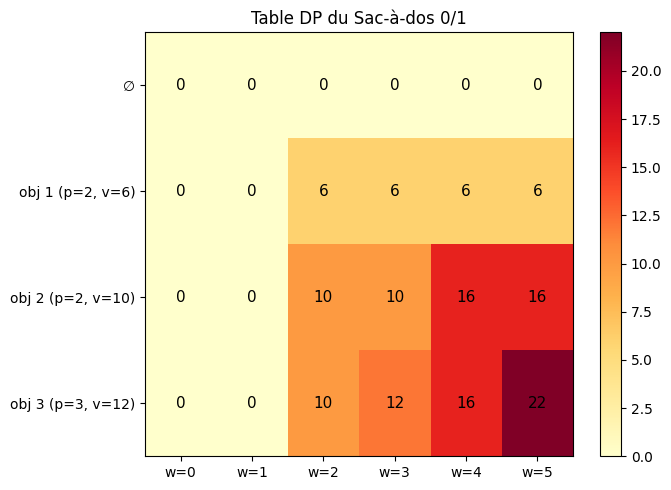

In [12]:
# ── Visualisation : table DP du sac-à-dos ─────────────────────────────────────
def knapsack_avec_table(poids, valeurs, W):
    """
    Version retournant la table complète pour visualisation.
    À implémenter en complétant knapsack.
    """
    n = len(poids)
    V = [[0] * (W + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(W + 1):
            V[i][w] = V[i-1][w]
            if poids[i-1] <= w:
                avec = valeurs[i-1] + V[i-1][w - poids[i-1]]
                if avec > V[i][w]:
                    V[i][w] = avec
    return V

V = knapsack_avec_table(poids, valeurs, W)

fig, ax = plt.subplots(figsize=(W + 2, len(poids) + 2))
data = np.array(V)
im = ax.imshow(data, cmap='YlOrRd', aspect='auto')
for i in range(len(poids) + 1):
    for j in range(W + 1):
        ax.text(j, i, str(V[i][j]), ha='center', va='center', fontsize=11)
ax.set_xticks(range(W + 1))
ax.set_xticklabels([f'w={j}' for j in range(W + 1)])
ax.set_yticks(range(len(poids) + 1))
ax.set_yticklabels(['∅'] + [f'obj {i+1} (p={poids[i]}, v={valeurs[i]})' for i in range(len(poids))])
ax.set_title('Table DP du Sac-à-dos 0/1')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('knapsack_table.png', dpi=100)
plt.show()

---
## Partie 6 : POO — Classe Abstraite `TableDP`

On unifie tous les algorithmes DP dans une classe abstraite commune.

In [13]:
from abc import ABC, abstractmethod

class TableDP(ABC):
    """
    Classe abstraite pour un problème de programmation dynamique.
    
    Chaque sous-classe implémente :
      - dimensions()     : tuple (nb_lignes, nb_colonnes)
      - cas_de_base()    : initialisation des bords
      - recurrence(i, j) : calcul de dp[i][j]
      - solution()       : lecture de la réponse
    """

    def __init__(self):
        dims = self.dimensions()
        self.dp = [[0] * dims[1] for _ in range(dims[0])]
        self._resolu = False

    @abstractmethod
    def dimensions(self):
        """Retourne (nb_lignes, nb_colonnes)."""
        
        pass

    @abstractmethod
    def cas_de_base(self):
        """Initialise les cas de base de la table."""
        pass

    @abstractmethod
    def recurrence(self, i, j):
        """Calcule dp[i][j]."""
        pass

    @abstractmethod
    def solution(self):
        """Retourne la solution lue dans la table."""
        pass

    def resoudre(self):
        """Remplit la table et retourne la solution."""
        self.cas_de_base()
        m, n = self.dimensions()
        for i in range(m):
            for j in range(n):
                self.recurrence(i, j)
        self._resolu = True
        return self.solution()

    def afficher_table(self):
        if not self._resolu:
            raise RuntimeError("Appelez resoudre() d'abord.")
        for ligne in self.dp:
            print('\t'.join(map(str, ligne)))

print("Classe TableDP définie.")

Classe TableDP définie.


In [14]:
class LCSTable(TableDP):
    """
    LCS implémentée via TableDP.
    Complétez les méthodes abstraites.
    """

    def __init__(self, X, Y):
        self.X, self.Y = X, Y
        self.m, self.n = len(X), len(Y)
        super().__init__()

    def dimensions(self):
        return (len(self.X) + 1, len(self.Y) + 1)
        

    def cas_de_base(self):
        pass  # Tous à 0 par défaut

    def recurrence(self, i, j):
        if i == 0 or j == 0:
            return
        
        if self.X[i-1] == self.Y[j-1]:
            self.dp[i][j] = self.dp[i-1][j-1] + 1
        else:
            self.dp[i][j] = max(self.dp[i-1][j], self.dp[i][j-1])
        #raise NotImplementedError("À implémenter")

    def solution(self):
        return self.dp[len(self.X)][len(self.Y)]
        #raise NotImplementedError("À implémenter")

# ── Tests ──────────────────────────────────────────────────────────────────────
lcs_obj = LCSTable("ABCBDAB", "BDCABA")
assert lcs_obj.resoudre() == 4
print("LCSTable : OK")

class LevenshteinTable(TableDP):
    """
    Distance de Levenshtein via TableDP.
    À implémenter (exercice).
    """
    def __init__(self, X, Y):
        self.X, self.Y = X, Y
        self.m, self.n = len(X), len(Y)
        super().__init__()

    def dimensions(self):
        return (self.m + 1, self.n + 1)
        #raise NotImplementedError("À implémenter")

    def cas_de_base(self):

        for i in range(self.m + 1):
            self.dp[i][0] = i
        for j in range(self.n + 1):
            self.dp[0][j] = j

        raise NotImplementedError("À implémenter")

    def recurrence(self, i, j):
        
        if i == 0 or j == 0:
            return  # Cas de base déjà initialisé
        
        # Coût de substitution : 0 si les caractères sont identiques, 1 sinon
        cout_substitution = 0 if self.X[i-1] == self.Y[j-1] else 1
        
        # Minimum entre :
        # - Suppression : dp[i-1][j] + 1
        # - Insertion   : dp[i][j-1] + 1
        # - Substitution: dp[i-1][j-1] + cout_substitution
        self.dp[i][j] = min(
            self.dp[i-1][j] + 1,                      # Suppression
            self.dp[i][j-1] + 1,                      # Insertion
            self.dp[i-1][j-1] + cout_substitution     # Substitution ou match
        )
        #raise NotImplementedError("À implémenter")

    def solution(self):
        #raise NotImplementedError("À implémenter")
        return self.dp[self.m][self.n]

LCSTable : OK


---
## Partie 7 : Analyse de Complexité et Mesures Empiriques

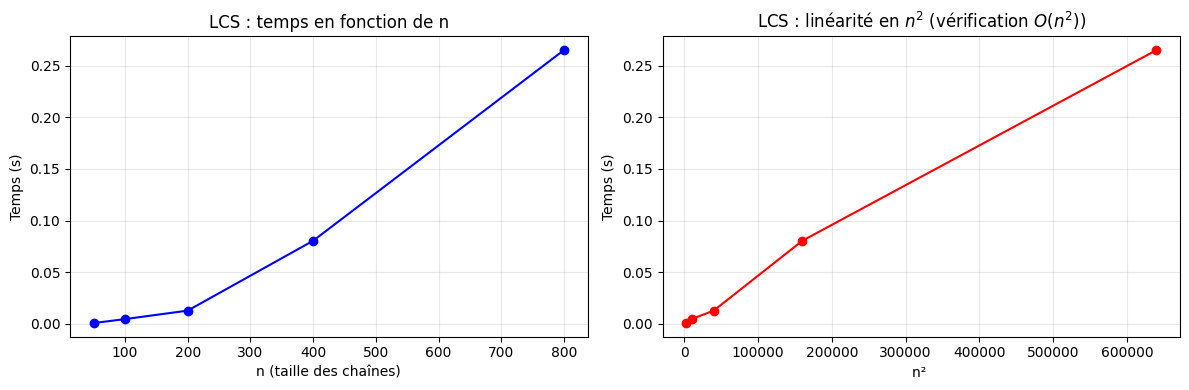


Tableau des mesures :
       n    Temps (s)        n^2
      50     0.000838       2500
     100     0.004681      10000
     200     0.012868      40000
     400     0.080447     160000
     800     0.264981     640000


In [15]:
# ── Complexité de la LCS : O(mn) ──────────────────────────────────────────────
# TODO : mesurez le temps de lcs_longueur pour des chaînes aléatoires
# de tailles n = m = 50, 100, 200, 400, 800.
# Tracez le temps en fonction de n^2 (vérification de O(n^2) pour m=n).

import random
import string

def chaine_aleatoire(n, alphabet='ACGT'):
    return ''.join(random.choices(alphabet, k=n))

tailles = [50, 100, 200, 400, 800]
temps_lcs = []

for n in tailles:
    X = chaine_aleatoire(n)
    Y = chaine_aleatoire(n)
    debut = time.perf_counter()
    lcs_longueur(X, Y)
    temps_lcs.append(time.perf_counter() - debut)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tailles, temps_lcs, 'b-o')
axes[0].set_xlabel('n (taille des chaînes)')
axes[0].set_ylabel('Temps (s)')
axes[0].set_title('LCS : temps en fonction de n')
axes[0].grid(True, alpha=0.3)

# Vérification de la loi O(n^2) : tracer t en fonction de n^2
n2 = [n**2 for n in tailles]
axes[1].plot(n2, temps_lcs, 'r-o')
axes[1].set_xlabel('n² ')
axes[1].set_ylabel('Temps (s)')
axes[1].set_title('LCS : linéarité en $n^2$ (vérification $O(n^2)$)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lcs_complexity.png', dpi=100)
plt.show()

print("\nTableau des mesures :")
print(f"{'n':>8} {'Temps (s)':>12} {'n^2':>10}")
for n, t in zip(tailles, temps_lcs):
    print(f"{n:>8} {t:>12.6f} {n**2:>10}")

n =  10, W = 500 → temps = 0.003833 s
n =  50, W = 500 → temps = 0.034281 s
n = 100, W = 500 → temps = 0.088109 s
n = 200, W = 500 → temps = 0.076073 s
n = 500, W = 500 → temps = 0.123429 s


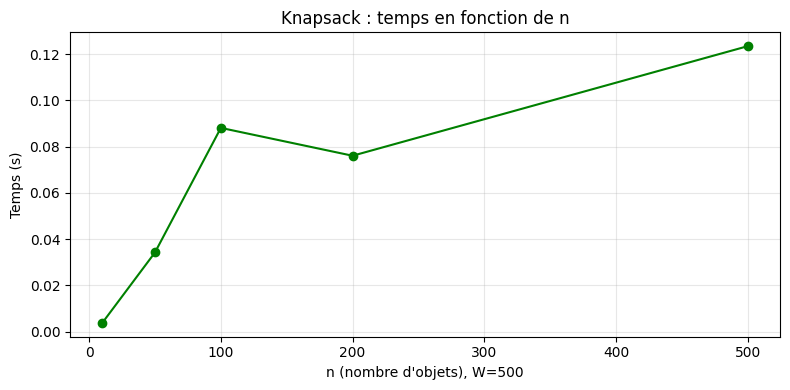

In [16]:
# ── Complexité du Knapsack : O(nW) ────────────────────────────────────────────
# TODO : mesurez le temps de knapsack en faisant varier
# (a) n (nombre d'objets) avec W fixé
# (b) W (capacité) avec n fixé
# Interprétez : pourquoi la complexité est dite pseudo-polynomiale ?

# Squelette
W_fixe = 500
n_values = [10, 50, 100, 200, 500]
temps_knapsack_n = []

for n in n_values:
    p = [random.randint(1, 50) for _ in range(n)]
    v = [random.randint(1, 100) for _ in range(n)]
    debut = time.perf_counter()
    knapsack(p, v, W_fixe)
    temps_knapsack_n.append(time.perf_counter() - debut)
    print(f"n = {n:3d}, W = {W_fixe:3d} → temps = {temps_knapsack_n[-1]:.6f} s")

plt.figure(figsize=(8, 4))
plt.plot(n_values, temps_knapsack_n, 'g-o')
plt.xlabel('n (nombre d\'objets), W=500')
plt.ylabel('Temps (s)')
plt.title('Knapsack : temps en fonction de n')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knapsack_complexity.png', dpi=100)
plt.show()

---
## Partie 8 : Exercices

Choisissez et résolvez **au moins 4 exercices** parmi les suivants.

### Exercice 1 : Nombres de Catalan

$$C_0 = 1, \quad C_n = \sum_{i=0}^{n-1} C_i \cdot C_{n-1-i}$$

(a) Version naïve, (b) avec `@memoize`, (c) tabulaire. Vérifiez $C_5 = 42$.

In [17]:
# (a) Version naïve

def catalan_naif(n):
    if n == 0:
        return 1
    return sum(catalan_naif(i) * catalan_naif(n - 1 - i) for i in range(n))

# (b) Version avec mémoïsation manuelle

def catalan_memo(n, cache=None):
    if cache is None:
        cache = {}
    if n in cache:
        return cache[n]
    if n == 0:
        return 1
    valeur = sum(catalan_memo(i, cache) * catalan_memo(n - 1 - i, cache) for i in range(n))
    cache[n] = valeur
    return valeur

# (c) Version tabulaire

def catalan_tab(n):
    if n < 0:
        raise ValueError("n doit être >= 0")
    C = [0] * (n + 1)
    C[0] = 1
    for k in range(1, n + 1):
        C[k] = sum(C[i] * C[k - 1 - i] for i in range(k))
    return C[n]

# Vérifications
assert catalan_naif(0) == 1
assert catalan_naif(5) == 42
assert catalan_memo(5) == 42
assert catalan_tab(5) == 42

print("C_0 à C_5 :", [catalan_tab(i) for i in range(6)])
print("C_5 =", catalan_tab(5))

C_0 à C_5 : [1, 1, 2, 5, 14, 42]
C_5 = 42


### Exercice 2 : Escalier (1, 2 ou 3 marches)

Trouvez $f(n)$ = nombre de façons de monter $n$ marches en avançant de 1, 2 ou 3 à la fois.

In [18]:
def escalier(n):
    """
    Nombre de façons de monter n marches (1, 2 ou 3 à la fois).
    Récurrence :
        f(0) = 1
        f(1) = 1
        f(2) = 2
        f(n) = f(n-1) + f(n-2) + f(n-3) pour n >= 3
    Complexité : O(n) temps, O(1) espace.
    """
    if n < 0:
        raise ValueError("n doit être >= 0")
    if n == 0:
        return 1
    if n == 1:
        return 1
    if n == 2:
        return 2

    a, b, c = 1, 1, 2  # f(0), f(1), f(2)
    for _ in range(3, n + 1):
        a, b, c = b, c, a + b + c
    return c

# Vérifications
assert escalier(0) == 1   # aucune marche
assert escalier(1) == 1   # {1}
assert escalier(2) == 2   # {1+1, 2}
assert escalier(3) == 4   # {1+1+1, 1+2, 2+1, 3}
assert escalier(4) == 7
assert escalier(10) == 274
print(f"escalier(10) = {escalier(10)}")

escalier(10) = 274


### Exercice 3 : Plus longue sous-chaîne commune (contiguë)

Contrairement à la LCS, la sous-chaîne doit être **contiguë**. Implémentez en $O(mn)$.

In [19]:
def plus_longue_sous_chaine_commune(X, Y):
    """
    Retourne la plus longue sous-chaîne (contiguë) commune à X et Y.
    Complexité : O(m*n) temps, O(m*n) espace.
    Idée : dp[i][j] = longueur de la plus longue sous-chaîne commune
    se terminant en X[i-1] et Y[j-1].
    """
    m, n = len(X), len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    meilleure_longueur = 0
    fin = 0

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i - 1] == Y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
                if dp[i][j] > meilleure_longueur:
                    meilleure_longueur = dp[i][j]
                    fin = i  # fin de la sous-chaîne dans X

    if meilleure_longueur == 0:
        return ""
    return X[fin - meilleure_longueur:fin]

# Vérifications
assert plus_longue_sous_chaine_commune("ABABC", "BABCAB") == "BABC"
assert plus_longue_sous_chaine_commune("abc", "xyz") == ""
assert plus_longue_sous_chaine_commune("AAAA", "AA") == "AA"
print("Plus longue sous-chaîne commune : OK")

Plus longue sous-chaîne commune : OK


### Exercice 4 : Sac-à-dos en espace $O(W)$

In [21]:
def knapsack_espace_lineaire(poids, valeurs, W):
    """
    Sac-à-dos 0/1 avec O(W) espace (une seule ligne).
    Attention : parcourir w de W vers 0 pour éviter de réutiliser
    le même objet deux fois.
    """
    dp = [0] * (W + 1)

    for i in range(len(poids)):
        for w in range(W, poids[i] - 1, -1):
            dp[w] = max(dp[w], valeurs[i] + dp[w - poids[i]])

    return dp[W]

val, _ = knapsack([2, 2, 3], [6, 10, 12], 5)
assert knapsack_espace_lineaire([2, 2, 3], [6, 10, 12], 5) == val
print("Knapsack espace linéaire : OK")

Knapsack espace linéaire : OK


### Exercice 5 : Fibonacci en $O(\log n)$ par exponentiation matricielle

$$\begin{pmatrix} F_{n+1} \\ F_n \end{pmatrix} = \begin{pmatrix} 1 & 1 \\ 1 & 0 \end{pmatrix}^n \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

In [ ]:
def mat_mul_2x2(A, B):
    """Multiplication de deux matrices 2x2."""
    return [
        [A[0][0] * B[0][0] + A[0][1] * B[1][0],
         A[0][0] * B[0][1] + A[0][1] * B[1][1]],
        [A[1][0] * B[0][0] + A[1][1] * B[1][0],
         A[1][0] * B[0][1] + A[1][1] * B[1][1]],
    ]


def mat_pow_2x2(M, n):
    """Exponentiation rapide d'une matrice 2x2."""
    result = [[1, 0], [0, 1]]
    base = M
    while n > 0:
        if n % 2 == 1:
            result = mat_mul_2x2(result, base)
        base = mat_mul_2x2(base, base)
        n //= 2
    return result


def fibonacci_matriciel(n):
    """
    F(n) par exponentiation matricielle en O(log n).
    Matrice de transition :
    [[1, 1],
     [1, 0]]
    """
    if n == 0:
        return 0
    M = [[1, 1], [1, 0]]
    P = mat_pow_2x2(M, n - 1)
    return P[0][0]  # F_n = (M^(n-1))[0][0] pour n >= 1

# Vérifications
for i, val in enumerate(premiers_fib):
    assert fibonacci_matriciel(i) == val, f"Erreur F_{i}"
assert fibonacci_matriciel(100) == fibonacci_tab(100)
print("fibonacci_matriciel : OK")

fibonacci_matriciel : OK


### Exercice 6 : Sous-tableau de somme maximale (Kadane)

Trouvez le sous-tableau contigu de somme maximale en $O(n)$.

In [22]:
def kadane(a):
    """
    Algorithme de Kadane : sous-tableau contigu de somme maximale.
    Retourne (somme_max, indice_debut, indice_fin).
    Complexité : O(n).
    Référence : CLRS, exercice 4.1-5.
    """
    if not a:
        return 0, -1, -1

    somme_courante = a[0]
    somme_max = a[0]
    debut_courant = debut_max = 0
    fin_max = 0

    for i in range(1, len(a)):
        if a[i] > somme_courante + a[i]:
            somme_courante = a[i]
            debut_courant = i
        else:
            somme_courante += a[i]

        if somme_courante > somme_max:
            somme_max = somme_courante
            debut_max = debut_courant
            fin_max = i

    return somme_max, debut_max, fin_max

a = [-2, 1, -3, 4, -1, 2, 1, -5, 4]
somme, debut, fin = kadane(a)
assert somme == 6, f"Somme attendue : 6, obtenu : {somme}"
assert a[debut:fin+1] == [4, -1, 2, 1]
print(f"Kadane : somme={somme}, sous-tableau={a[debut:fin+1]} : OK")

Kadane : somme=6, sous-tableau=[4, -1, 2, 1] : OK


---
## Partie 9 : Introduction Lean 4

Copiez et exécutez ces exemples dans votre éditeur Lean 4 (VS Code + extension Lean4).

```lean
import Mathlib.Data.List.Basic
import Mathlib.Data.Nat.Basic

-- La liste vide est sous-séquence de toute liste
example (xs : List Nat) : List.Sublist [] xs := by
  exact List.nil_sublist xs

-- Toute liste est sous-séquence d'elle-même
example (xs : List Nat) : List.Sublist xs xs := by
  exact List.Sublist.refl xs

-- Longueur d'une sous-séquence bornée par la liste originale
example (xs ys : List Nat) (h : List.Sublist xs ys) :
    xs.length ≤ ys.length := by
  exact List.Sublist.length_le h

-- Exercice : montrer que la concaténation avec une liste vide
-- donne la même liste
example (xs : List Nat) : xs ++ [] = xs := by
  exact List.append_nil xs
```

**Sauvegardez vos preuves dans `seance4.lean`.**

---
## Récapitulatif des complexités

| Algorithme | Temps | Espace | Note |
|---|---|---|---|
| Fibonacci naïf | $O(2^n)$ | $O(n)$ | inutilisable |
| Fibonacci mémoïsé | $O(n)$ | $O(n)$ | top-down |
| Fibonacci tabulaire | $O(n)$ | $O(1)$ | optimal |
| Fibonacci matriciel | $O(\log n)$ | $O(1)$ | exponentiation rapide |
| LCS | $O(mn)$ | $O(mn)$ | reconstruction possible |
| LCS espace optimisé | $O(mn)$ | $O(\min(m,n))$ | sans reconstruction |
| Levenshtein | $O(mn)$ | $O(mn)$ | |
| Knapsack 0/1 | $O(nW)$ | $O(nW)$ | pseudo-polynomial |
| Knapsack espace lin. | $O(nW)$ | $O(W)$ | sans reconstruction |

---
## Livrable

Déposez dans votre dépôt GitHub `M1-Informatique` :
- Ce notebook complété : `seance4.ipynb`
- Le fichier Lean : `seance4.lean`
- Un commit : `"Séance 4 : Programmation Dynamique"`

**Critères :** Fibonacci ×3 + LCS + Levenshtein + Knapsack (4 pts) · Classe `TableDP` (1 pt) · Complexité + graphiques (2 pts) · ≥4 exercices (2 pts) · Documentation + Git (1 pt)